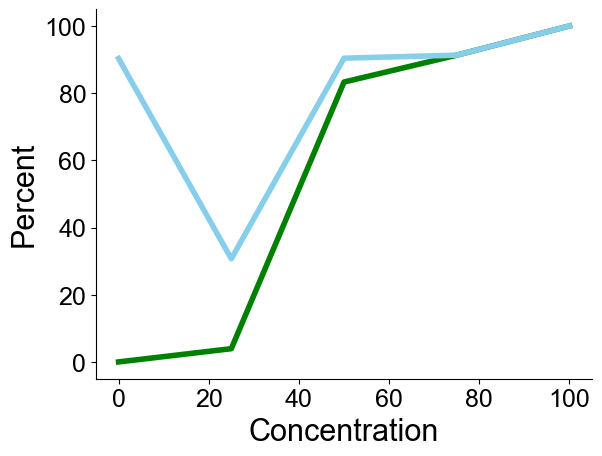

In [126]:
import matplotlib.pyplot as plt

# data import
concentration = [0, 25, 50, 75, 100]
percent_eating = [0, 003.94, 083.3, 091.3, 100]
percent_near_food = [090.3, 030.7, 090.4, 091.3, 100]

# plot both datasets
plt.plot(concentration, percent_eating, label='Percent Eating', linestyle='-', color='green', linewidth=4)
plt.plot(concentration, percent_near_food, label='Percent Near Food', linestyle='-', color='skyblue', linewidth=4)

# labels and title
plt.xlabel('Concentration', fontsize=22, fontname="arial")
plt.ylabel('Percent', fontsize=22, fontname="arial")

# make tick labels larger
plt.xticks(fontsize=18, fontname="arial")
plt.yticks(fontsize=18, fontname="arial")

# remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# display
plt.show()


Eating comparison p-value: 0.0025883151492780854
Near food comparison p-value: 0.3634760503358323


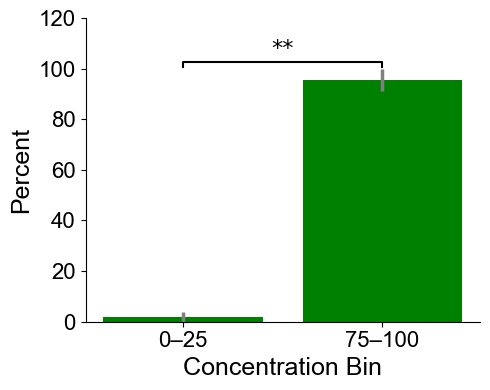

Eating means: (np.float64(1.97), np.float64(95.65))
Eating SE: (np.float64(1.97), np.float64(4.350000000000001))


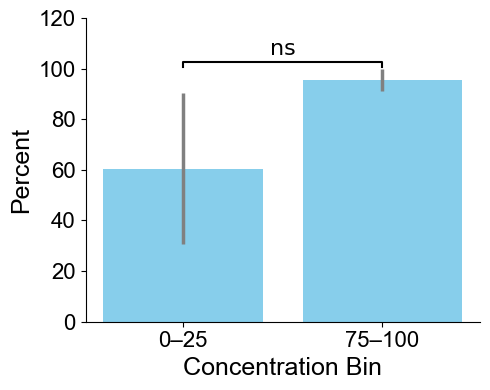

Near food means: (np.float64(60.5), np.float64(95.65))
Near food SE: (np.float64(29.8), np.float64(4.350000000000001))


In [131]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

# Corrected data (values multiplied by 100, no leading zeros)
percent_eating = [0, 3.94, 83.3, 91.3, 100]
percent_near_food = [90.3, 30.7, 90.4, 91.3, 100]

# ---- BINNING ----
# Bin 1: 0 + 25
# Bin 2: 75 + 100
bin_labels = ['0–25', '75–100']

eating_bins = [
    [percent_eating[0], percent_eating[1]],  # bin 1
    [percent_eating[3], percent_eating[4]]   # bin 2
]
near_food_bins = [
    [percent_near_food[0], percent_near_food[1]],  # bin 1
    [percent_near_food[3], percent_near_food[4]]   # bin 2
]

# Helper function for mean and SE
def mean_se(data):
    data = np.array(data)
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return mean, se

# Calculate means and SEs
eating_means, eating_se = zip(*[mean_se(b) for b in eating_bins])
near_means, near_se = zip(*[mean_se(b) for b in near_food_bins])

# statistical analysis
t_eat, p_eat = ttest_ind(eating_bins[0], eating_bins[1])
t_near, p_near = ttest_ind(near_food_bins[0], near_food_bins[1])

print("Eating comparison p-value:", p_eat)
print("Near food comparison p-value:", p_near)

def significance_label(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"  # not significant

# ---------------------------------------------------------------------
# 1️⃣ PLOT 1: Percent Eating
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5,4))
bars = ax.bar(bin_labels, eating_means, yerr=eating_se, 
              error_kw=dict(lw=2.5, ecolor='gray'), color='green')

ax.set_xlabel('Concentration Bin', fontsize=18, fontname='Arial')
ax.set_ylabel('Percent', fontsize=18, fontname='Arial')
plt.xticks(fontsize=16, fontname="Arial")
plt.yticks(fontsize=16, fontname="Arial")

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# significance annotation
x1, x2 = 0, 1
y, h = max(eating_means) + 5, 2
sig_label = significance_label(p_eat)
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
ax.text((x1+x2)*0.5, y+h+1, sig_label, ha='center', va='bottom', fontsize=16)

ax.set_ylim(0, 120)
plt.tight_layout()
plt.show()

print("Eating means:", eating_means)
print("Eating SE:", eating_se)

# ---------------------------------------------------------------------
# 2️⃣ PLOT 2: Percent Near Food
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5,4))
bars = ax.bar(bin_labels, near_means, yerr=near_se, 
              error_kw=dict(lw=2.5, ecolor='gray'), color='skyblue')

ax.set_xlabel('Concentration Bin', fontsize=18, fontname='Arial')
ax.set_ylabel('Percent', fontsize=18, fontname='Arial')
plt.xticks(fontsize=16, fontname="Arial")
plt.yticks(fontsize=16, fontname="Arial")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# significance annotation
x1, x2 = 0, 1
y, h = max(near_means) + 5, 2
sig_label = significance_label(p_near)
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
ax.text((x1+x2)*0.5, y+h+1, sig_label, ha='center', va='bottom', fontsize=16)

ax.set_ylim(0, 120)
plt.tight_layout()
plt.show()

print("Near food means:", near_means)
print("Near food SE:", near_se)


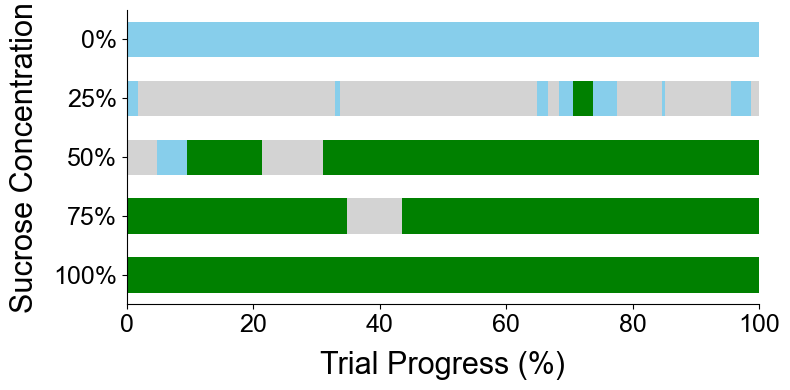

In [134]:
import matplotlib.pyplot as plt

# Define color mapping for each behavior
color_map = {
    'near': 'skyblue',
    'lick': 'green',
    'stop': 'lightgray'
}

# ---- Data for each trial (converted to percentages) ----
trials = {
    1: {
        'time': [0, 100],
        'state': ['near', 'stop']
    },
    2: {
        'time': [t * 100 for t in [0, 0.0175, 0.329, 0.338, 0.649, 0.667, 0.684, 0.706, 0.737, 0.776, 0.846, 0.851, 0.956, 0.987, 1]],
        'state': ['near', 'stop', 'near', 'stop', 'near', 'stop', 'near', 'lick', 'near', 'stop', 'near', 'stop', 'near', 'stop', 'stop']
    },
    3: {
        'time': [t * 100 for t in [0, 0.0476, 0.0952, 0.214, 0.31, 1]],
        'state': ['stop', 'near', 'lick', 'stop', 'lick', 'stop']
    },
    4: {
        'time': [t * 100 for t in [0, 0.348, 0.435, 1]],
        'state': ['lick', 'stop', 'lick', 'stop']
    },
    5: {
        'time': [0, 100],
        'state': ['lick', 'stop']
    }
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 4))

for i, (trial, data) in enumerate(trials.items(), start=1):
    times = data['time']
    states = data['state']

    # draw colored rectangles between time intervals
    for j in range(len(times) - 1):
        ax.barh(
            y=i,
            width=times[j+1] - times[j],
            left=times[j],
            color=color_map[states[j]],
            edgecolor='none',
            height=0.6
        )

# ---- Formatting ----
ax.set_xlim(0, 100)
ax.set_ylim(0.5, len(trials) + 0.5)
ax.set_xlabel('Trial Progress (%)', fontsize=22, fontname='Arial', labelpad=10)
ax.set_ylabel('Sucrose Concentration', fontsize=22, fontname='Arial', labelpad=10)

# Larger tick font sizes
plt.xticks(fontsize=18, fontname="Arial")
plt.yticks(fontsize=18, fontname="Arial")

ax.set_yticks(range(1, len(trials) + 1))
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()  # trial 1 on top


plt.tight_layout()
plt.show()


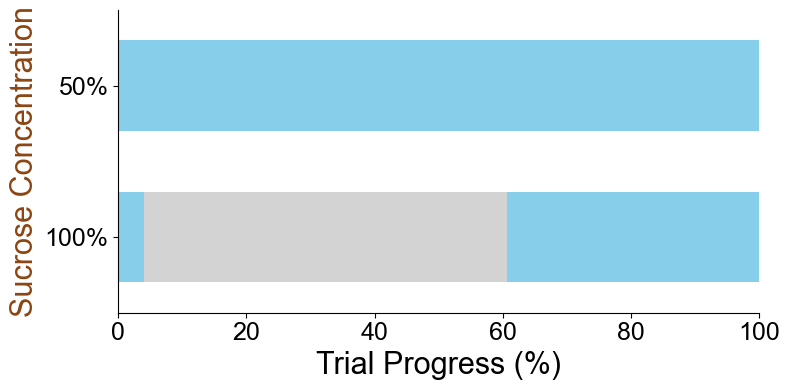

In [144]:
import matplotlib.pyplot as plt

# Color mapping for each behavior
color_map = {
    'near': 'skyblue',
    'lick': 'green',
    'stop': 'lightgray'
}

# ---- Data for eucalyptus (0% sucrose) trials ----
trials = {
    2: {
        'time': [0, 100],  # converted to percent
        'state': ['near', 'stop']
    },
    3: {
        'time': [t * 100 for t in [0, 0.0394, 0.606, 1]],  # convert to percent
        'state': ['near', 'stop', 'near', 'stop']
    }
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 4))

for i, (trial, data) in enumerate(trials.items(), start=1):
    times = data['time']
    states = data['state']
    
    for j in range(len(times) - 1):
        ax.barh(
            y=i,
            width=times[j+1] - times[j],
            left=times[j],
            color=color_map[states[j]],
            edgecolor='none',
            height=0.6
        )

# ---- Formatting ----
ax.set_xlim(0, 100)
ax.set_ylim(0.5, len(trials) + 0.5)
ax.set_xlabel('Trial Progress (%)', fontsize=22, fontname='Arial')
ax.set_ylabel('Sucrose Concentration', fontsize=22, fontname='Arial', color='saddlebrown')
ax.set_yticks(range(1, len(trials) + 1))
ax.set_yticklabels(['50%', '100%'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()  # trial 1 on top

# Larger, clean tick labels
plt.xticks(fontsize=18, fontname="Arial")
plt.yticks(fontsize=18, fontname="Arial")

plt.tight_layout()
plt.show()


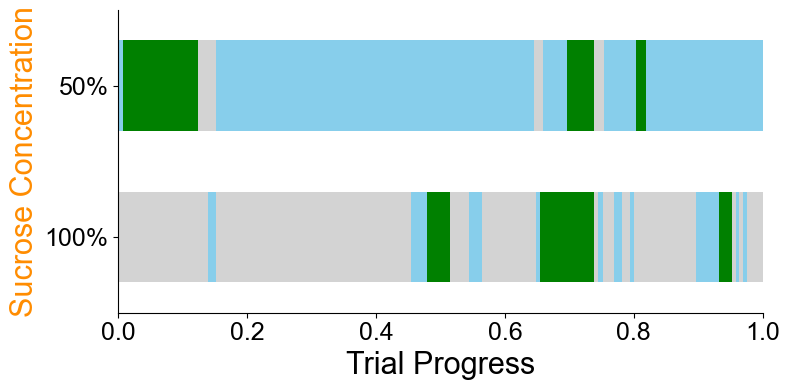

In [143]:
import matplotlib.pyplot as plt

# Color mapping for behaviors
color_map = {
    'near': 'skyblue',
    'lick': 'green',
    'stop': 'lightgray'
}

# ---- Eucalyptus (Sucrose) trials ----
trials = {
    '50%': {
        'time': [0, 0.00725, 0.123, 0.152, 0.645, 0.659, 0.696, 0.739, 0.754, 0.804, 0.819, 1],
        'state': ['near', 'lick', 'stop', 'near', 'stop', 'near', 'lick', 'stop', 'near', 'lick', 'near', 'stop']
    },
    '100%': {
        'time': [0, 0.139, 0.152, 0.455, 0.479, 0.515, 0.545, 0.564, 0.648, 0.655, 0.739, 0.745, 0.752, 0.77, 0.782, 0.794, 0.8, 0.897, 0.933, 0.952, 0.958, 0.964, 0.97, 0.976, 1],
        'state': ['stop', 'near', 'stop', 'near', 'lick', 'stop', 'near', 'stop', 'near', 'lick', 'stop', 'near', 'stop', 'near', 'stop', 'near', 'stop', 'near', 'lick', 'stop', 'near', 'stop', 'near', 'stop', 'stop']
    }
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 4))

for i, (label, data) in enumerate(trials.items(), start=1):
    times = data['time']
    states = data['state']

    for j in range(len(times) - 1):
        ax.barh(
            y=i,
            width=times[j+1] - times[j],
            left=times[j],
            color=color_map[states[j]],
            edgecolor='none',
            height=0.6
        )

# ---- Formatting ----
ax.set_xlim(0, 1)
ax.set_ylim(0.5, len(trials) + 0.5)
ax.set_xlabel('Trial Progress', fontsize=22, fontname='Arial')
ax.set_ylabel('Sucrose Concentration', fontsize=22, fontname='Arial', color='darkorange')
ax.set_yticks(range(1, len(trials) + 1))
ax.set_yticklabels(['50%', '100%'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()  # 50% on top
plt.xticks(fontsize=18, fontname="Arial")
plt.yticks(fontsize=18, fontname="Arial")

plt.tight_layout()
plt.show()


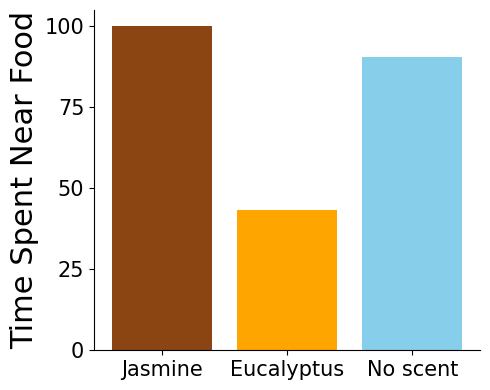

In [154]:
import matplotlib.pyplot as plt
#eucalyptus 50% near
# --- Data ---
x = ['Jasmine', 'Eucalyptus', 'No scent']   # labels for bars
y = [100, 43.4, 90.5]                 # heights of bars

colors = ['saddlebrown','orange', 'skyblue']  # Group A = brown, Group B = blue


# --- Plot ---
fig, ax = plt.subplots(figsize=(5,4))

bars = ax.bar(x, y, color=colors, edgecolor='none')

# --- Labels and Titles ---
ax.set_ylabel('Time Spent Near Food', fontsize=22)

# --- Customize Ticks ---
ax.set_xticks(range(len(x)))         # optional if you want full control
ax.set_xticklabels(x, fontsize=15)   # label x-axis ticks
ax.set_yticks([0, 25, 50, 75, 100])    # custom y-axis tick positions
ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=15)

# --- Style tweaks ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


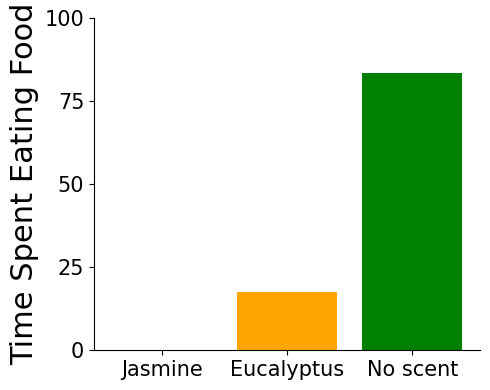

In [153]:
import matplotlib.pyplot as plt
#eucalyptus 50% eat
# --- Data ---
x = ['Jasmine', 'Eucalyptus', 'No scent']   # labels for bars
y = [0,17.4, 83.3]                 # heights of bars

colors = ['saddlebrown', 'orange', 'green']  # Group A = brown, Group B = blue

# --- Plot ---
fig, ax = plt.subplots(figsize=(5,4))

bars = ax.bar(x, y, color=colors, edgecolor='none')

# --- Labels and Titles ---
ax.set_ylabel('Time Spent Eating Food', fontsize=22)


# --- Customize Ticks ---
ax.set_xticks(range(len(x)))         # optional if you want full control
ax.set_xticklabels(x, fontsize=15)   # label x-axis ticks
ax.set_yticks([0, 25, 50, 75, 100])    # custom y-axis tick positions
ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=15)

# --- Style tweaks ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


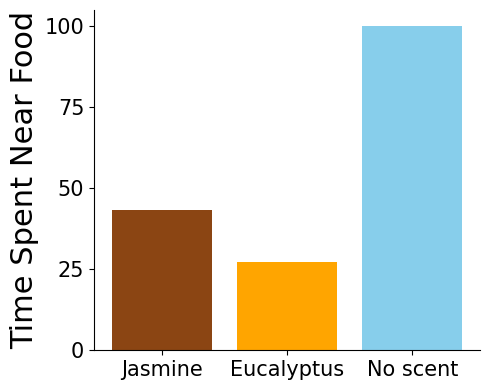

In [152]:
import matplotlib.pyplot as plt
#eucalyptus 100% near
# --- Data ---
x = ['Jasmine', 'Eucalyptus', 'No scent']   # labels for bars
y = [43.3, 27.3, 100]                 # heights of bars

colors = ['saddlebrown','orange', 'skyblue']  # Group A = brown, Group B = blue


# --- Plot ---
fig, ax = plt.subplots(figsize=(5,4))

bars = ax.bar(x, y, color=colors, edgecolor='none')

# --- Labels and Titles ---
ax.set_ylabel('Time Spent Near Food', fontsize=22)

# --- Customize Ticks ---
ax.set_xticks(range(len(x)))         # optional if you want full control
ax.set_xticklabels(x, fontsize=15)   # label x-axis ticks
ax.set_yticks([0, 25, 50, 75, 100])    # custom y-axis tick positions
ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=15)

# --- Style tweaks ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


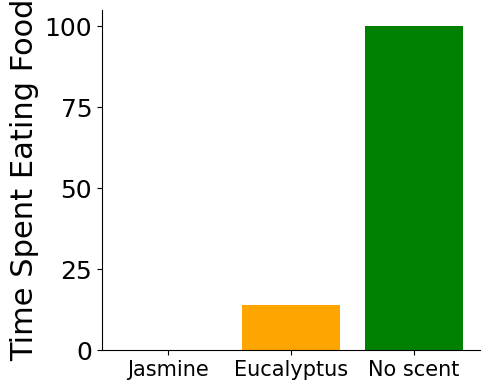

In [151]:
import matplotlib.pyplot as plt
#eucalyptus 100% eat
# --- Data ---
x = ['Jasmine', 'Eucalyptus', 'No scent']   # labels for bars
y = [0, 13.9, 100]                 # heights of bars

colors = ['saddlebrown','orange', 'green']  # Group A = brown, Group B = blue


# --- Plot ---
fig, ax = plt.subplots(figsize=(5,4))

bars = ax.bar(x, y, color=colors, edgecolor='none')

# --- Labels and Titles ---
ax.set_ylabel('Time Spent Eating Food', fontsize=22)

# --- Customize Ticks ---
ax.set_xticks(range(len(x)))         # optional if you want full control
ax.set_xticklabels(x, fontsize=15)   # label x-axis ticks
ax.set_yticks([0, 25, 50, 75, 100])    # custom y-axis tick positions
ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=18)

# --- Style tweaks ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
